In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu ĐÃ LÀM SẠCH
df = pd.read_csv("traffic_clean.csv")

### Chọn các Features quan trọng

Chọn 10 features dễ hiểu và có ý nghĩa thực tế:

In [60]:
# Chọn các cột features quan trọng
selected_features = [
    'weather_condition',           # Điều kiện thời tiết
    'lighting_condition',          # Điều kiện ánh sáng
    'roadway_surface_cond',        # Tình trạng mặt đường
    'first_crash_type',            # Loại va chạm
    'crash_hour',                  # Giờ xảy ra tai nạn
    'crash_day_of_week',           # Ngày trong tuần
    'crash_month',                 # Tháng
    'num_units',                   # Số phương tiện
    'prim_contributory_cause',     # Nguyên nhân chính
    'traffic_control_device'       # Thiết bị điều khiển giao thông
]

# Tạo dataframe mới với features đã chọn và target
df_model = df[selected_features + ['is_severe']].copy()

print(f"\n Đã chọn {len(selected_features)} features cho mô hình")
print(f"Kích thước dữ liệu mới: {df_model.shape}")


 Đã chọn 10 features cho mô hình
Kích thước dữ liệu mới: (103450, 11)


---
## PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

### 1. Phân phối biến mục tiêu

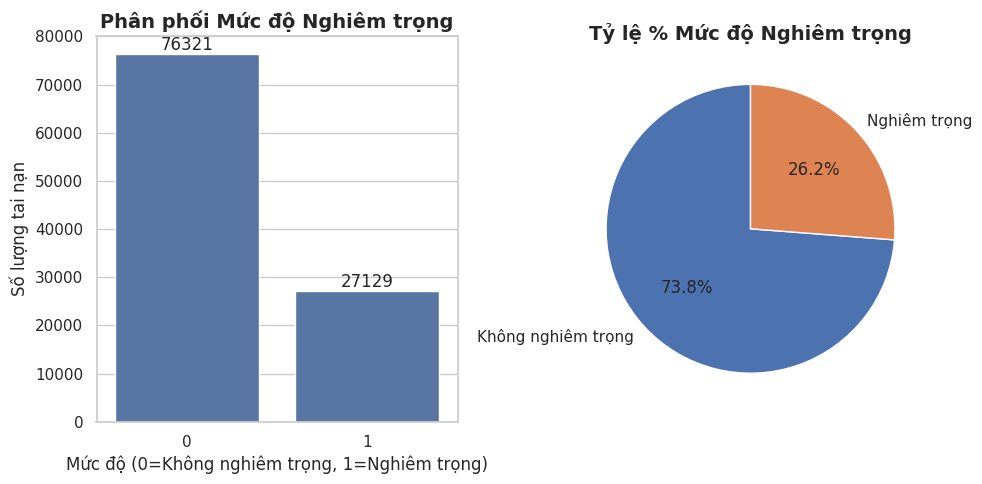


Nhận xét: Dữ liệu BỊ MẤT CÂN BẰNG - cần áp dụng SMOTE!


In [61]:
# Vẽ biểu đồ phân phối target
plt.figure(figsize=(10, 5))

# Countplot
plt.subplot(1, 2, 1)
ax = sns.countplot(data=df_model, x='is_severe')
plt.title('Phân phối Mức độ Nghiêm trọng', fontsize=14, fontweight='bold')
plt.xlabel('Mức độ (0=Không nghiêm trọng, 1=Nghiêm trọng)')
plt.ylabel('Số lượng tai nạn')
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

# Pie chart
plt.subplot(1, 2, 2)
counts = df_model['is_severe'].value_counts()
plt.pie(counts, labels=['Không nghiêm trọng', 'Nghiêm trọng'], autopct='%1.1f%%', startangle=90)
plt.title('Tỷ lệ % Mức độ Nghiêm trọng', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNhận xét: Dữ liệu BỊ MẤT CÂN BẰNG - cần áp dụng SMOTE!")

### 2. Phân tích theo Điều kiện Ánh sáng

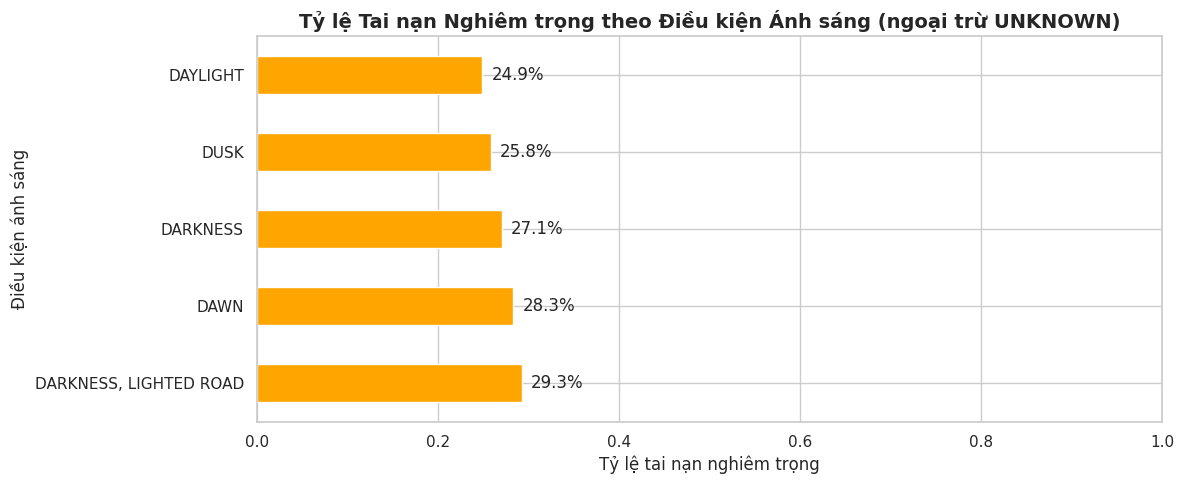


Điều kiện ánh sáng NGUY HIỂM NHẤT: DARKNESS, LIGHTED ROAD
   Tỷ lệ tai nạn nghiêm trọng: 29.29%

Top 3 điều kiện ánh sáng nguy hiểm:
   1. DARKNESS, LIGHTED ROAD: 29.29%
   2. DAWN: 28.33%
   3. DARKNESS: 27.08%


In [62]:
# Tính tỷ lệ tai nạn nghiêm trọng theo điều kiện ánh sáng
# Loại bỏ UNKNOWN trước khi phân tích
df_lighting = df_model[~df_model['lighting_condition'].astype(str).str.upper().str.contains('UNKNOWN')]
lighting_severity = df_lighting.groupby('lighting_condition')['is_severe'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ax = lighting_severity.plot(kind='barh', color='orange')
plt.title('Tỷ lệ Tai nạn Nghiêm trọng theo Điều kiện Ánh sáng (ngoại trừ UNKNOWN)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ tai nạn nghiêm trọng')
plt.ylabel('Điều kiện ánh sáng')
plt.xlim(0, 1)
for i, v in enumerate(lighting_severity):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

# In ra điều kiện ánh sáng nguy hiểm nhất
most_dangerous = lighting_severity.index[0]
highest_rate = lighting_severity.iloc[0]
print(f"\nĐiều kiện ánh sáng NGUY HIỂM NHẤT: {most_dangerous}")
print(f"   Tỷ lệ tai nạn nghiêm trọng: {highest_rate:.2%}")
print(f"\nTop 3 điều kiện ánh sáng nguy hiểm:")
for i, (condition, rate) in enumerate(lighting_severity.head(3).items(), 1):
    print(f"   {i}. {condition}: {rate:.2%}")

### 3. Phân tích theo Điều kiện Thời tiết

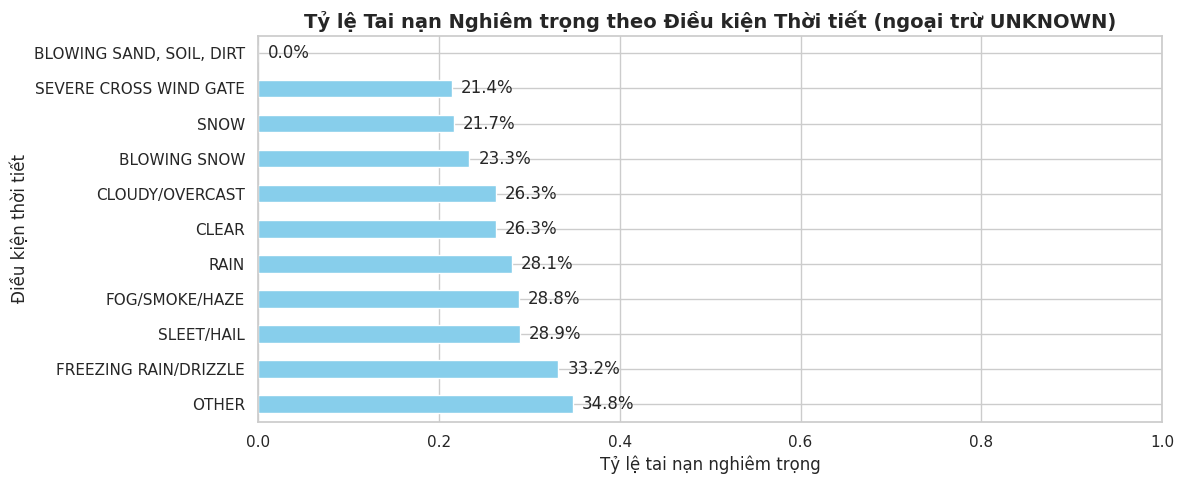


Điều kiện thời tiết NGUY HIỂM NHẤT: OTHER
   Tỷ lệ tai nạn nghiêm trọng: 34.81%

Top 3 điều kiện thời tiết nguy hiểm:
   1. OTHER: 34.81%
   2. FREEZING RAIN/DRIZZLE: 33.20%
   3. SLEET/HAIL: 28.92%


In [63]:
# Tính tỷ lệ tai nạn nghiêm trọng theo thời tiết
# Loại bỏ UNKNOWN trước khi phân tích
df_weather = df_model[~df_model['weather_condition'].astype(str).str.upper().str.contains('UNKNOWN')]
weather_severity = df_weather.groupby('weather_condition')['is_severe'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
ax = weather_severity.plot(kind='barh', color='skyblue')
plt.title('Tỷ lệ Tai nạn Nghiêm trọng theo Điều kiện Thời tiết (ngoại trừ UNKNOWN)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ tai nạn nghiêm trọng')
plt.ylabel('Điều kiện thời tiết')
plt.xlim(0, 1)
for i, v in enumerate(weather_severity):
    plt.text(v + 0.01, i, f'{v:.1%}', va='center')
plt.tight_layout()
plt.show()

# In ra điều kiện thời tiết nguy hiểm nhất
most_dangerous_weather = weather_severity.index[0]
highest_rate_weather = weather_severity.iloc[0]
print(f"\nĐiều kiện thời tiết NGUY HIỂM NHẤT: {most_dangerous_weather}")
print(f"   Tỷ lệ tai nạn nghiêm trọng: {highest_rate_weather:.2%}")
print(f"\nTop 3 điều kiện thời tiết nguy hiểm:")
for i, (condition, rate) in enumerate(weather_severity.head(3).items(), 1):
    print(f"   {i}. {condition}: {rate:.2%}")

### 4. Phân tích theo Giờ trong Ngày

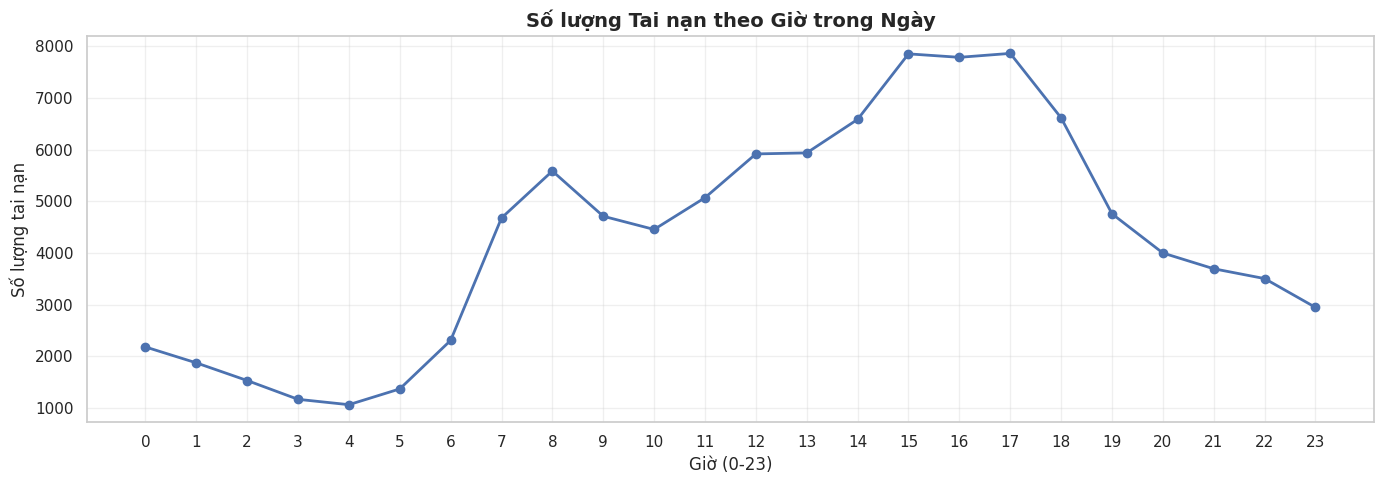


Giờ có NHIỀU TAI NẠN NHẤT: 17.0h
   Số lượng tai nạn: 7,863

Top 5 giờ có nhiều tai nạn:
   1. 17.0h: 7,863 tai nạn
   2. 15.0h: 7,854 tai nạn
   3. 16.0h: 7,787 tai nạn
   4. 18.0h: 6,615 tai nạn
   5. 14.0h: 6,586 tai nạn


In [64]:
# Số lượng tai nạn theo giờ
hourly_accidents = df_model['crash_hour'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
plt.plot(hourly_accidents.index, hourly_accidents.values, marker='o', linewidth=2, markersize=6)
plt.title('Số lượng Tai nạn theo Giờ trong Ngày', fontsize=14, fontweight='bold')
plt.xlabel('Giờ (0-23)')
plt.ylabel('Số lượng tai nạn')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tìm giờ có nhiều tai nạn nhất
peak_hour = hourly_accidents.idxmax()
peak_count = hourly_accidents.max()
print(f"\nGiờ có NHIỀU TAI NẠN NHẤT: {peak_hour}h")
print(f"   Số lượng tai nạn: {peak_count:,}")
print(f"\nTop 5 giờ có nhiều tai nạn:")
for i, (hour, count) in enumerate(hourly_accidents.nlargest(5).items(), 1):
    print(f"   {i}. {hour}h: {count:,} tai nạn")

### 5. Top 10 Loại Va chạm

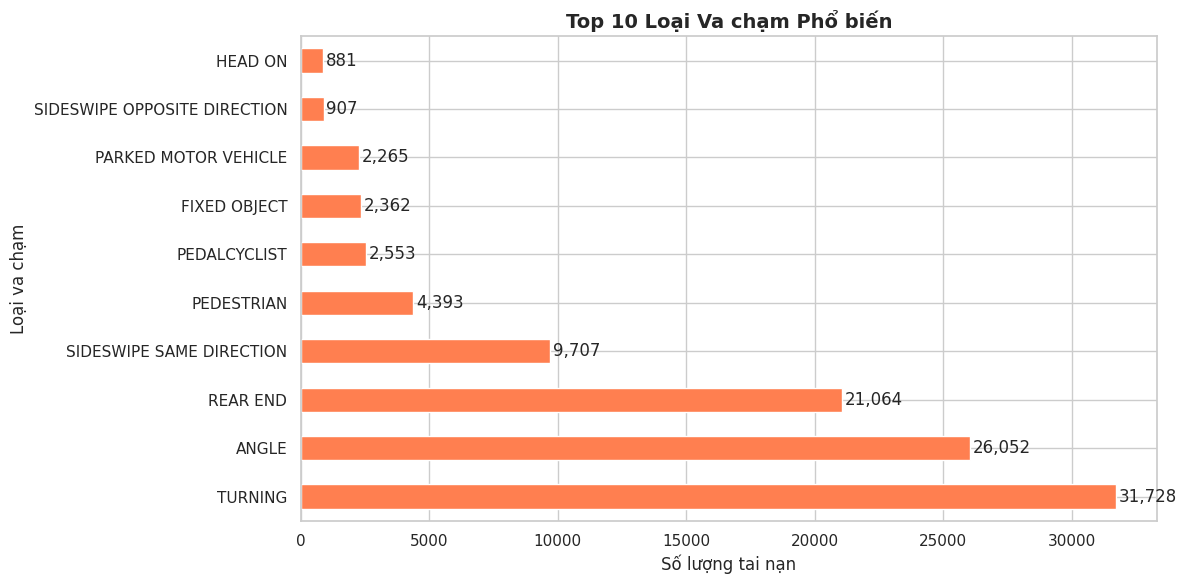


Loại va chạm THƯỜNG XUYÊN NHẤT: TURNING
   Số lượng: 31,728 tai nạn (30.67%)

Top 3 loại va chạm phổ biến:
   1. TURNING: 31,728 tai nạn
   2. ANGLE: 26,052 tai nạn
   3. REAR END: 21,064 tai nạn


In [65]:
# Top 10 loại va chạm
top_crash_types = df_model['first_crash_type'].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = top_crash_types.plot(kind='barh', color='coral')
plt.title('Top 10 Loại Va chạm Phổ biến', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng tai nạn')
plt.ylabel('Loại va chạm')
for i, v in enumerate(top_crash_types):
    plt.text(v + 100, i, f'{v:,}', va='center')
plt.tight_layout()
plt.show()

# Tìm loại va chạm thường xuyên nhất
most_common_crash = top_crash_types.index[0]
most_common_count = top_crash_types.iloc[0]
print(f"\nLoại va chạm THƯỜNG XUYÊN NHẤT: {most_common_crash}")
print(f"   Số lượng: {most_common_count:,} tai nạn ({most_common_count/len(df_model)*100:.2f}%)")
print(f"\nTop 3 loại va chạm phổ biến:")
for i, (crash_type, count) in enumerate(top_crash_types.head(3).items(), 1):
    print(f"   {i}. {crash_type}: {count:,} tai nạn")

### 6. Phân tích Độ quan trọng của Features (Feature Importance Analysis)

**Lưu ý:** Do dataset có 6 biến categorical và 4 biến numerical, chúng ta sử dụng:
- **Chi-Square Test**: Đánh giá mối liên hệ giữa categorical features và target
- **Mutual Information**: Xếp hạng tất cả features (không phân biệt loại dữ liệu)

In [66]:
from scipy.stats import chi2_contingency

categorical_cols = [
    'weather_condition', 'lighting_condition', 'roadway_surface_cond',
    'first_crash_type', 'prim_contributory_cause', 'traffic_control_device'
]

chi2_results = []

for col in categorical_cols:
    # Tạo contingency table
    contingency = pd.crosstab(df_model[col], df_model['is_severe'])

    # Tính chi-square
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)

    chi2_results.append({
        'Feature': col,
        'Chi2_Statistic': chi2_stat,
        'P_Value': p_value,
        'DOF': dof,
        'Significant': 'YES' if p_value < 0.05 else 'NO'
    })

# Sắp xếp theo Chi2 giảm dần
chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2_Statistic', ascending=False)

print("\nKết quả Chi-Square Test:")
print(chi2_df.to_string(index=False))
print(f"\nTất cả {(chi2_df['P_Value'] < 0.05).sum()}/{len(chi2_df)} features có ý nghĩa thống kê (p < 0.05)")


Kết quả Chi-Square Test:
                Feature  Chi2_Statistic      P_Value  DOF Significant
       first_crash_type    16809.454163 0.000000e+00   17         YES
prim_contributory_cause     4937.260841 0.000000e+00   39         YES
   roadway_surface_cond      305.674462 4.974452e-63    6         YES
 traffic_control_device      244.151962 3.257623e-42   17         YES
     lighting_condition      197.534628 1.273177e-41    4         YES
      weather_condition      168.097984 2.904845e-30   11         YES

Tất cả 6/6 features có ý nghĩa thống kê (p < 0.05)


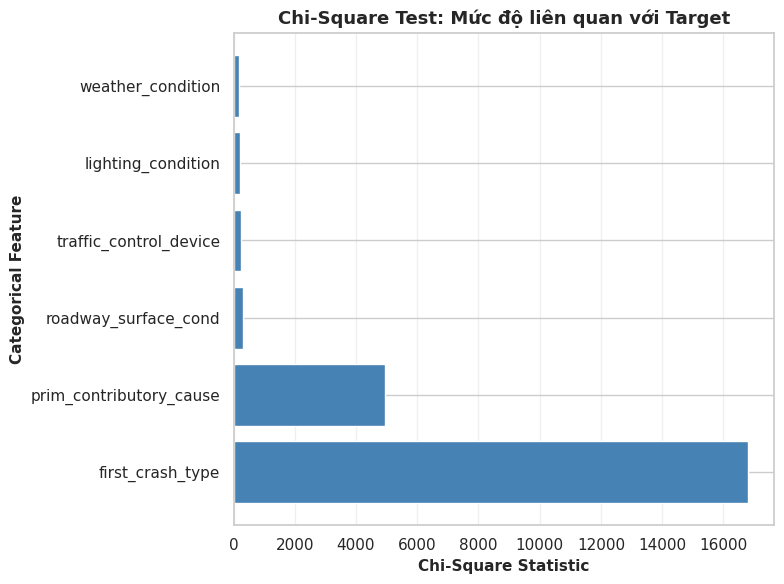

In [67]:
# Visualization Chi-Square Test
fig, ax1 = plt.subplots(figsize=(8, 6))

# Plot: Chi-Square Statistics
ax1.barh(chi2_df['Feature'], chi2_df['Chi2_Statistic'], color='steelblue')
ax1.set_xlabel('Chi-Square Statistic', fontsize=11, fontweight='bold')
ax1.set_ylabel('Categorical Feature', fontsize=11, fontweight='bold')
ax1.set_title('Chi-Square Test: Mức độ liên quan với Target', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)


plt.tight_layout()
plt.show()

In [70]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Encode categorical features (chỉ cho mục đích feature selection)
df_for_mi = df_model.copy()

# # Identify numerical columns (excluding the target 'is_severe')
# numerical_cols = [col for col in df_for_mi.columns if col not in categorical_cols and col != 'is_severe']

# # Handle NaNs: Fill categorical NaNs with 'Missing' and numerical NaNs with median
# for col in categorical_cols:
#     if df_for_mi[col].isnull().any():
#         df_for_mi[col] = df_for_mi[col].fillna('Missing')

# for col in numerical_cols:
#     if df_for_mi[col].isnull().any():
#         df_for_mi[col] = df_for_mi[col].fillna(df_for_mi[col].median())

label_encoders_mi = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_for_mi[col] = le.fit_transform(df_for_mi[col])
    label_encoders_mi[col] = le

# Tách X và y
X_mi = df_for_mi.drop('is_severe', axis=1)
y_mi = df_for_mi['is_severe']

# Tính Mutual Information
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features='auto', random_state=42)

# Tạo DataFrame kết quả
mi_results = pd.DataFrame({
    'Feature': X_mi.columns,
    'MI_Score': mi_scores,
    'Feature_Type': ['Categorical' if col in categorical_cols else 'Numerical'
                     for col in X_mi.columns]
}).sort_values('MI_Score', ascending=False)

print("\nMutual Information Scores:")
print(mi_results.to_string(index=False))

print(f"\nTOP 5 FEATURES QUAN TRỌNG NHẤT (theo MI):")
for idx, row in mi_results.head(5).iterrows():
    print(f"   {idx+1}. {row['Feature']: <30} | MI = {row['MI_Score']:.5f} | Type: {row['Feature_Type']}")

print(f"\n5 FEATURES ÍT QUAN TRỌNG NHẤT (theo MI):")
for idx, row in mi_results.tail(5).iterrows():
    print(f"   • {row['Feature']: <30} | MI = {row['MI_Score']:.5f} | Type: {row['Feature_Type']}")


Mutual Information Scores:
                Feature  MI_Score Feature_Type
       first_crash_type  0.080920  Categorical
prim_contributory_cause  0.025658  Categorical
              num_units  0.019275    Numerical
     lighting_condition  0.009994  Categorical
      weather_condition  0.007086  Categorical
 traffic_control_device  0.007067  Categorical
   roadway_surface_cond  0.002529  Categorical
      crash_day_of_week  0.002002    Numerical
             crash_hour  0.001759    Numerical
            crash_month  0.001439    Numerical

TOP 5 FEATURES QUAN TRỌNG NHẤT (theo MI):
   4. first_crash_type               | MI = 0.08092 | Type: Categorical
   9. prim_contributory_cause        | MI = 0.02566 | Type: Categorical
   8. num_units                      | MI = 0.01927 | Type: Numerical
   2. lighting_condition             | MI = 0.00999 | Type: Categorical
   1. weather_condition              | MI = 0.00709 | Type: Categorical

5 FEATURES ÍT QUAN TRỌNG NHẤT (theo MI):
   • traffic

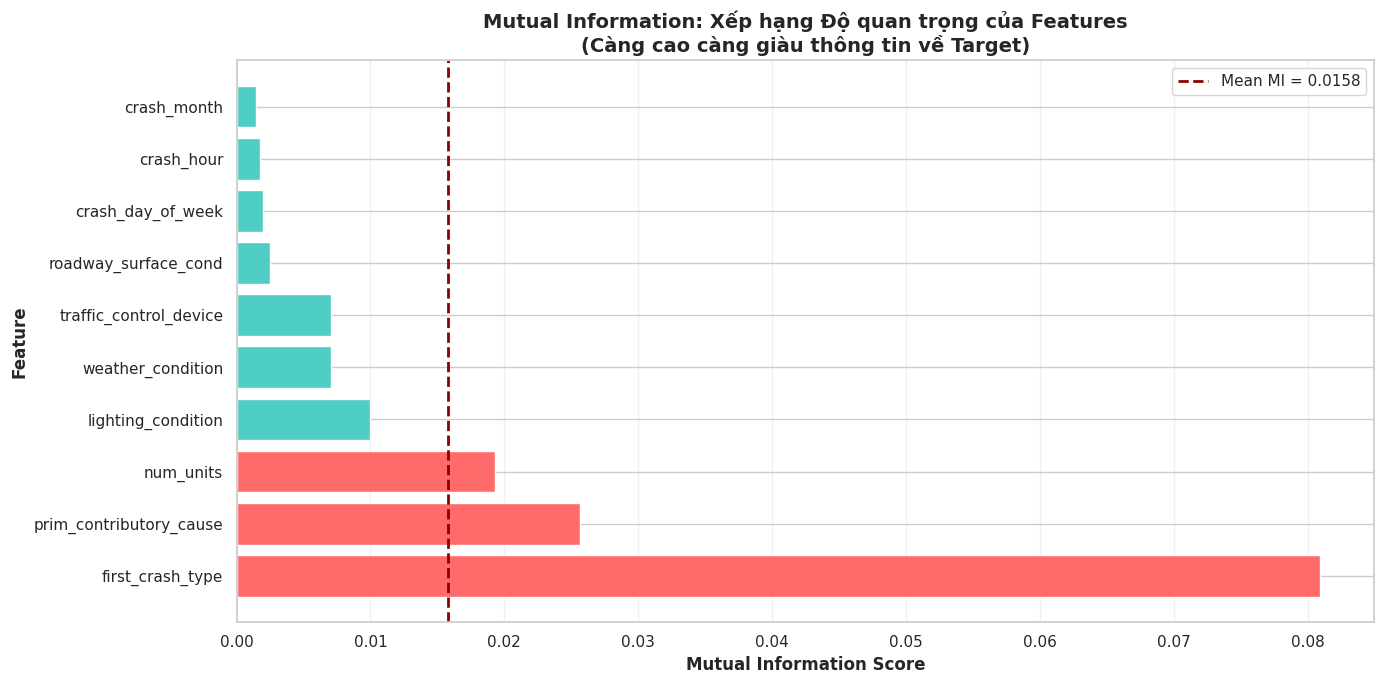

In [71]:
# Visualization Mutual Information
plt.figure(figsize=(14, 7))
colors = ['#FF6B6B' if score > mi_results['MI_Score'].mean() else '#4ECDC4'
          for score in mi_results['MI_Score']]

plt.barh(mi_results['Feature'], mi_results['MI_Score'], color=colors)
plt.axvline(x=mi_results['MI_Score'].mean(), color='darkred', linestyle='--',
            linewidth=2, label=f'Mean MI = {mi_results["MI_Score"].mean():.4f}')
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Mutual Information: Xếp hạng Độ quan trọng của Features\n(Càng cao càng giàu thông tin về Target)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()